In [1]:
import os.path, time
import onnxruntime as ort
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from utils.miscellaneous import create_seq_dataset_multiple_input_single_output
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from matplotlib.ticker import MultipleLocator, LogLocator
from tqdm.notebook import tqdm

In [2]:
seq_len = 20
model = ort.InferenceSession(f'models/model_{seq_len}.onnx')

In [3]:
feature_name_list = ['inlet_pressure(bar)', 'outlet_pressure(bar)', 'pump_speed(rpm)']
target_name = 'outlet_flowrate(lpm)'

file_name_list = os.listdir(os.path.join('data', 'train_data'))
data_list = []

for file_name in file_name_list:
    file_path = os.path.join('data', 'train_data', file_name)
    data = pd.read_csv(file_path)
    data.columns = ['time(sec)'] + feature_name_list + [target_name]

    max_time = np.round(data['time(sec)'].max(), 0)
    time_ref_arr = np.arange(0, max_time, 0.5)
    sorted_data = []

    for ref_time in time_ref_arr:
        idx = np.argmin(np.abs(data['time(sec)'].to_numpy() - ref_time))
        sorted_data.append(data.iloc[idx, :])

    sorted_data = pd.DataFrame(sorted_data)
    sorted_data.reset_index(drop=True, inplace=True)
    data_list.append(sorted_data)

train_data = pd.concat(data_list, axis=0)

train_dataset = train_data.copy()
train_dataset = train_dataset[train_dataset[feature_name_list[2]] > 700]
train_dataset = train_dataset[train_dataset[target_name] > 100]
train_dataset.reset_index(drop=True, inplace=True)

train_dataset = train_dataset[feature_name_list+[target_name]].to_numpy()
train_dataset.shape

(3572, 4)

In [4]:
feature_name_list = ['pump_inlet_pressure(bar)', 'pump_outlet_pressure(bar)', 'pump_speed(rpm)']
target_name = 'venturi_flowrate(lpm)'

test_data_list = ['data/test_data/data20251117-142801.csv',
                  'data/test_data/data20251117-143219.csv',
                  'data/test_data/data20251117-143505.csv',
                  'data/test_data/data20251117-143657.csv',
                  'data/test_data/data20251117-143831.csv']

data_list = []

for test_data_name in test_data_list:
    data = pd.read_csv(test_data_name)
    data = data[['time(sec)']+feature_name_list+[target_name]]

    max_time = np.round(data['time(sec)'].max(), 0)
    time_ref_arr = np.arange(0, max_time, 0.5)
    sorted_data = []

    for ref_time in time_ref_arr:
        idx = np.argmin(np.abs(data['time(sec)'].to_numpy() - ref_time))
        sorted_data.append(data.iloc[idx, :])

    sorted_data = pd.DataFrame(sorted_data)
    sorted_data.reset_index(drop=True, inplace=True)
    data_list.append(sorted_data)

val_data = pd.concat(data_list, axis=0)

val_dataset = val_data.copy()
val_dataset = val_dataset[val_dataset[feature_name_list[2]] > 700]
val_dataset = val_dataset[val_dataset[target_name] > 100]
val_dataset.reset_index(drop=True, inplace=True)

val_dataset = val_dataset[feature_name_list+[target_name]]
val_dataset_arr = val_dataset.to_numpy()
val_dataset_arr.shape

(1485, 4)

In [5]:
n_of_features = len(feature_name_list)

input_buf = np.zeros(shape=(1, seq_len, n_of_features), dtype=np.float32)

est_flow_arr = []
gt_flow_arr = []

for sig_set in tqdm(train_dataset):
    input_buf = np.roll(a=input_buf, shift=-1, axis=1)
    input_buf[0, -1, :] = sig_set[0:3]

    est_flow = np.squeeze(model.run(output_names=None, input_feed={'input': input_buf})).item()
    est_flow_arr.append(est_flow)
    gt_flow_arr.append(sig_set[3])

est_flow_arr = np.array(est_flow_arr)
gt_flow_arr = np.array(gt_flow_arr)

print(r2_score(gt_flow_arr, est_flow_arr))
print(mean_absolute_error(gt_flow_arr, est_flow_arr))
print(mean_absolute_percentage_error(gt_flow_arr, est_flow_arr))

  0%|          | 0/3572 [00:00<?, ?it/s]

0.9455458220907142
399.470203171477
0.06980566184270923


In [17]:
n_of_features = len(feature_name_list)

input_buf = np.zeros(shape=(1, seq_len, n_of_features), dtype=np.float32)

val_pred = []
val_target = []

dataset = np.concatenate([train_dataset, val_dataset_arr], axis=0)

for sig_set in tqdm(val_dataset_arr):
    input_buf = np.roll(a=input_buf, shift=-1, axis=1)
    input_buf[0, -1, :] = sig_set[0:3]

    est_flow = np.squeeze(model.run(output_names=None, input_feed={'input': input_buf})).item()
    val_pred.append(est_flow)

val_pred = np.array(val_pred)
val_target = np.array(val_dataset_arr[:, 3])

print(r2_score(val_target, val_pred))
print(mean_absolute_error(val_target, val_pred))
print(mean_absolute_percentage_error(val_target, val_pred))

  0%|          | 0/1485 [00:00<?, ?it/s]

0.9388643311778797
405.6955884759049
0.0391521001200207


In [18]:
print(dataset[:, 0].min(), dataset[:, 0].max())
print(dataset[:, 1].min(), dataset[:, 1].max())
print(dataset[:, 2].min(), dataset[:, 2].max())
print(dataset[:, 3].min(), dataset[:, 3].max())

-0.466 0.202
3.383 14.922
770.0 1551.0
156.355 16592.809


In [19]:
val_abs_error = np.abs(val_target-val_pred)
val_rela_error = (val_abs_error / val_target)*100

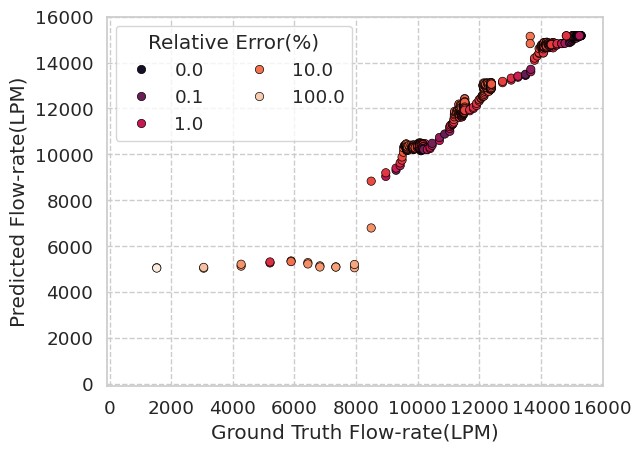

In [20]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

axis = sns.scatterplot(x=val_target, y=val_pred, edgecolor='black', hue=val_rela_error, hue_norm=colors.LogNorm(), palette="rocket")

plt.xlim(-100, 16000)
plt.xlabel('Ground Truth Flow-rate(LPM)')

plt.ylim(-100, 16000)
plt.ylabel('Predicted Flow-rate(LPM)')

plt.legend(title='Relative Error(%)', ncol=2)

legend = axis.get_legend()
labels = legend.get_texts()

for text_obj in labels:
    text = text_obj.get_text()
    corrected_string = text.replace('−', '-')
    numeric_value = float(corrected_string)
    text_obj.set_text(f'{numeric_value:0.1f}')

In [21]:
val_data.shape

(1592, 5)

In [22]:
len(val_pred)

1485

In [23]:
print(val_target.max())

flow_range = np.array(range(0, int(val_target.max())+1000, 1000))

val_result_df = pd.DataFrame({'Ground Truth Flow Rate(LPM)': val_target, 'Predicted Flow Rate(LPM)': val_pred, 'Absolute Error(LPM)': val_abs_error, 'Relative Error(%)': val_rela_error})
val_result_df = pd.concat([val_dataset, val_result_df], axis=1)

refine_val_result = []

for idx in range(len(flow_range)-1):
    flow_df = val_result_df[(val_result_df['Ground Truth Flow Rate(LPM)'] >= flow_range[idx]) & (val_result_df['Predicted Flow Rate(LPM)'] < flow_range[idx+1])]
    flow_df.reset_index(drop=True, inplace=True)
    refine_val_result.append(flow_df)

flow_result = []

for flow in refine_val_result:
    flow_result.append([flow['Relative Error(%)'].mean(), flow['Relative Error(%)'].std(), flow['Absolute Error(LPM)'].mean(), flow['Absolute Error(LPM)'].std()])

flow_result = np.array(flow_result)
flow_result = pd.DataFrame(np.hstack([flow_range[1:].reshape(-1, 1), flow_result]),
                           columns=['Flow Rate(LPM)', 'Mean Relative Error(%)', 'Std Relative Error(%)', 'Mean Absolute Error(LPM)', 'Std Absolute Error(LPM)'])

15305.789


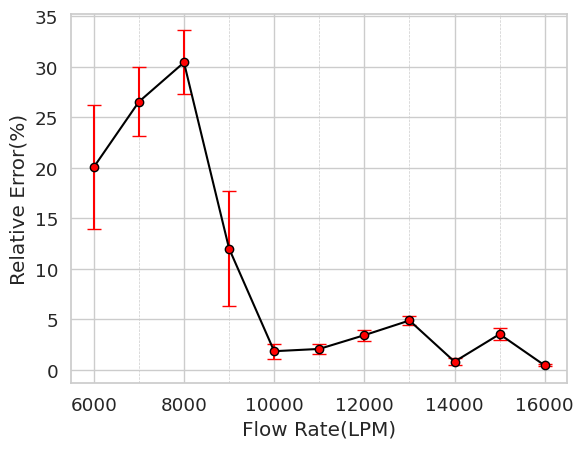

In [24]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

plt.errorbar(flow_result['Flow Rate(LPM)'], flow_result['Mean Relative Error(%)'], yerr=flow_result['Std Relative Error(%)']/2,
             marker='o', markeredgecolor='black', markerfacecolor='red', capsize=5, color='black', ecolor='red')
plt.gca().xaxis.set_major_locator(MultipleLocator(2000))
plt.gca().xaxis.set_minor_locator(MultipleLocator(1000))

#plt.xlim(0, 16000)
plt.xlabel('Flow Rate(LPM)')

#plt.ylim(1, 1100)
#plt.yscale('log')
plt.ylabel('Relative Error(%)')

#plt.gca().yaxis.set_major_locator(LogLocator(base=10))

plt.grid(True, which='major', linestyle='-', linewidth=1.0)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)

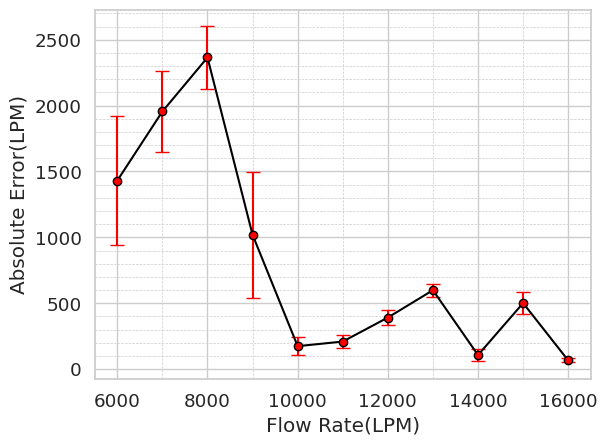

In [25]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

plt.errorbar(flow_result['Flow Rate(LPM)'], flow_result['Mean Absolute Error(LPM)'], yerr=flow_result['Std Absolute Error(LPM)']/2,
             marker='o', markeredgecolor='black', markerfacecolor='red', capsize=5, color='black', ecolor='red')
plt.gca().xaxis.set_major_locator(MultipleLocator(2000))
plt.gca().xaxis.set_minor_locator(MultipleLocator(1000))

#plt.xlim(0, 2500)
plt.xlabel('Flow Rate(LPM)')

#plt.ylim(0, 250)
#plt.yscale('log')
plt.ylabel('Absolute Error(LPM)')

#plt.gca().yaxis.set_major_locator(LogLocator(base=10))
plt.gca().yaxis.set_minor_locator(MultipleLocator(100))

plt.grid(True, which='major', linestyle='-', linewidth=1.0)
plt.grid(True, which='minor', linestyle='--', linewidth=0.5)

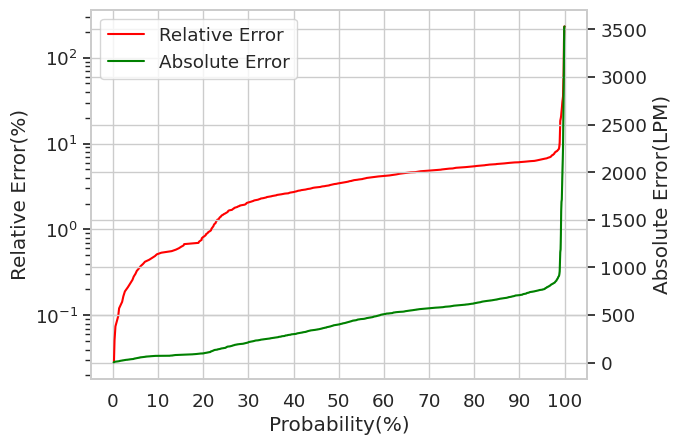

In [26]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid')

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

rela_error_hist = np.histogram(val_rela_error, bins=10000)
cum_rela_error_hist = np.cumsum(rela_error_hist[0])
cum_rela_error_hist = cum_rela_error_hist/np.max(cum_rela_error_hist)

abs_error_hist = np.histogram(val_abs_error, bins=10000)
cum_abs_error_hist = np.cumsum(abs_error_hist[0])
cum_abs_error_hist = cum_abs_error_hist/np.max(cum_abs_error_hist)

sns.lineplot(x=cum_rela_error_hist*100, y=rela_error_hist[1][1:], ax=ax1, color='red') # label 없어도 됨
ax1.set_xlabel('Probability(%)')
#ax1.set_ylim(1, 1000)
ax1.set_yscale('log')
ax1.set_ylabel('Relative Error(%)')

ax1.xaxis.set_major_locator(MultipleLocator(10))

sns.lineplot(x=cum_abs_error_hist*100, y=abs_error_hist[1][1:], ax=ax2, color='green') # label 없어도 됨
ax2.set_ylabel('Absolute Error(LPM)')

line1 = ax1.lines[0]
line2 = ax2.lines[0]

ax2.legend(handles=[line1, line2], labels=['Relative Error', 'Absolute Error'], loc='upper left')

plt.grid(True, which='major', linestyle='-', linewidth=1.0)
plt.show()

In [69]:
val_dataset_1 = pd.concat([val_dataset,
                           pd.DataFrame(val_pred, columns=['Predicted Flow Rate(LPM)']),
                           pd.DataFrame(val_rela_error, columns=['relative_error']),
                           pd.DataFrame(val_abs_error, columns=['abs_error'])], axis=1)
val_dataset_1

,pump_inlet_pressure(bar),pump_outlet_pressure(bar),pump_speed(rpm),venturi_flowrate(lpm),Predicted Flow Rate(LPM),relative_error,abs_error
0,-0.145,4.716,918.0,1530.382,5061.762695,230.751583,3531.380695
1,-0.296,4.927,919.0,1530.382,5048.920898,229.912460,3518.538898
2,-0.267,4.994,920.0,3054.540,5044.113281,65.134956,1989.573281
3,-0.270,5.021,921.0,3054.540,5077.156738,66.216738,2022.616738
4,-0.218,5.037,918.0,4269.533,5132.912109,20.221863,863.379109
...,...,...,...,...,...,...,...
1480,-0.148,10.740,1059.0,15253.091,15169.264648,0.549570,83.826352
1481,-0.185,7.625,937.0,14826.782,15169.304688,2.310162,342.522688
1482,-0.164,6.049,877.0,14826.782,15166.367188,2.290350,339.585188
1483,-0.165,4.826,808.0,13653.602,15141.968750,10.900909,1488.366750


In [74]:
bool_idx_1 = (val_dataset_1['pump_speed(rpm)'] > 1050) & (val_dataset_1['pump_speed(rpm)'] < 1150)

low_val_list = [1, 2000, 4000, 6000, 8000, 10000, 12000, 14000]
high_val_list = [2000, 4000, 6000, 8000, 10000, 12000, 14000, 16000]

for low_val, high_val in zip(low_val_list, high_val_list):
    bool_idx_2 = bool_idx_1 & (val_dataset_1['venturi_flowrate(lpm)'] > low_val) & (val_dataset_1['venturi_flowrate(lpm)'] < high_val)
    print(val_dataset_1[bool_idx_1 & bool_idx_2]['abs_error'].mean())

nan
nan
562.5576757812496
1987.672631347656
529.9569454708615
214.22178046657388
nan
83.82635156250035


In [75]:
val_dataset_1.corr()

,pump_inlet_pressure(bar),pump_outlet_pressure(bar),pump_speed(rpm),venturi_flowrate(lpm),Predicted Flow Rate(LPM),relative_error,abs_error
pump_inlet_pressure(bar),1.000000,-0.436403,-0.437066,-0.405214,-0.402898,0.033889,0.073992
pump_outlet_pressure(bar),-0.436403,1.000000,0.993322,0.963345,0.945844,-0.185314,-0.225690
pump_speed(rpm),-0.437066,0.993322,1.000000,0.952789,0.936737,-0.198865,-0.216814
venturi_flowrate(lpm),-0.405214,0.963345,0.952789,1.000000,0.985574,-0.327454,-0.306485
Predicted Flow Rate(LPM),-0.402898,0.945844,0.936737,0.985574,1.000000,-0.261839,-0.220978
relative_error,0.033889,-0.185314,-0.198865,-0.327454,-0.261839,1.000000,0.662518
abs_error,0.073992,-0.225690,-0.216814,-0.306485,-0.220978,0.662518,1.000000
